Nombres: Yoana Boyanova Boncheva y Víctor Piquero Moreno

# Uso de K-Means en el mercado de valores

Se dispone de un dataset de 60 grandes multinacionales de diversos ámbitos de la economía (Tecnológicas, Hardware, Farmacéuticas, Energéticas, Automoción, Aeroespacial, Limpieza, Financieras, Alimentación) y su evolución en el mercado de acciones diaria a lo largo de 3 años (son datos reales obtenidos de una web de inversión).
Vamos a usar K-Means para averiguar si la evolución financiera de las empresas de un mismo ámbito es parecida a lo largo del tiempo. Los datos están almacenados en un fichero csv llamado 'company_stocks.csv'

Vamos a considerar toda la evolución de una compañía como un vector multidimensional donde cada característica es el valor de un día de mercado.
Vamos a tener por tanto 60 puntos (datos) con una dimensión  de 963.

Carga las librerías de Panda, numpy, matplotlib.pyplot, e importa de sklearn.preprocessing el método normalize, de sklearn.cluster  el método KMeans y de sklearn.decomposition  el método PCA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Carga en un dataframe los datos del fichero csv,visualiza los 5 primeros datos con *'head()'* para ver su estructura y **divide este dataframe en dos partes, por una parte los nombres de las compañías (primera columna) y por otra la matriz de 60X963 características**.
**Haz las transformaciones de dataframe a lista y luego a un numpy array de estas estructuras** para luego poder procesarlas en los métodos de sklearn. Comprueba que el tamaño de la matriz de datos que has creado es el correcto.

In [5]:
df = pd.read_csv('company_stocks.csv')

print("Primeras filas del dataset:")
display(df.head())

company_names = df.iloc[:, 0].tolist()      
data = df.iloc[:, 1:].values               

print("\nNúmero de compañías:", len(company_names))
print("Forma de la matriz de datos:", data.shape) 

Primeras filas del dataset:


,Unnamed: 0,2010-01-04,2010-01-05,2010-01-06,2010-01-07,2010-01-08,2010-01-11,2010-01-12,2010-01-13,2010-01-14,...,2013-10-16,2013-10-17,2013-10-18,2013-10-21,2013-10-22,2013-10-23,2013-10-24,2013-10-25,2013-10-28,2013-10-29
0,Apple,0.580000,-0.220005,-3.409998,-1.170000,1.680011,-2.689994,-1.469994,2.779997,-0.680003,...,0.320008,4.519997,2.899987,9.590019,-6.540016,5.959976,6.910011,-5.359962,0.840019,-19.589981
1,AIG,-0.640002,-0.650000,-0.210001,-0.420000,0.710001,-0.200001,-1.130001,0.069999,-0.119999,...,0.919998,0.709999,0.119999,-0.480000,0.010002,-0.279998,-0.190003,-0.040001,-0.400002,0.660000
2,Amazon,-2.350006,1.260009,-2.350006,-2.009995,2.960006,-2.309997,-1.640007,1.209999,-1.790001,...,2.109985,3.699982,9.570008,-3.450013,4.820008,-4.079986,2.579986,4.790009,-1.760009,3.740021
3,American express,0.109997,0.000000,0.260002,0.720002,0.190003,-0.270001,0.750000,0.300004,0.639999,...,0.680001,2.290001,0.409996,-0.069999,0.100006,0.069999,0.130005,1.849999,0.040001,0.540001
4,Boeing,0.459999,1.770000,1.549999,2.690003,0.059997,-1.080002,0.360000,0.549999,0.530002,...,1.559997,2.480003,0.019997,-1.220001,0.480003,3.020004,-0.029999,1.940002,1.130005,0.309998



Número de compañías: 60
Forma de la matriz de datos: (60, 963)


## Preprocesamiento
Fíjate que los valores de algunas características son más altos que los de otras. Esto es perjudicial para el análisis si estamos usando métricas como la euclídea, ya que unas características pueden tener más peso que otras en el cálculo de la distancia. Es necesario normalizar los datos.
En este caso, como las características son valores en el tiempo y representan la misma propiedad (el valor de la empresa en el mercado) el **preprocesamiento adecuado es la normalización de cada uno de los datos** (no la normalización por características). 




In [7]:
data_normalized = normalize(data, axis=1)

print("\nForma de la matriz normalizada:", data_normalized.shape)

#Te debe salir una matriz de talla (60, 963)


Forma de la matriz normalizada: (60, 963)


## Análisis del número de clusters
Vamos a hacer un estudio del número de clusters adecuado para este dataset. Vamos a generar una curva (llamada en muchos libros *'elbow curve'*) donde representamos en abcisas el número de clusters *'K'* y en ordenadas la Inercia media de los clusters. Este valor está definido como atributo de KMeans bajo el nombre de *'inertia_'*.
Para ello vamos a ejecutar 20 procesos diferentes de KMeans cada uno de ellos con un K diferente desde 2 a 20 y construiremos un vector con los *'inertia_*' resultantes que visualizaremos en la gráfica

Completa el siguiente código que visualiza la curva

C:\Users\victo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\victo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\victo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\victo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

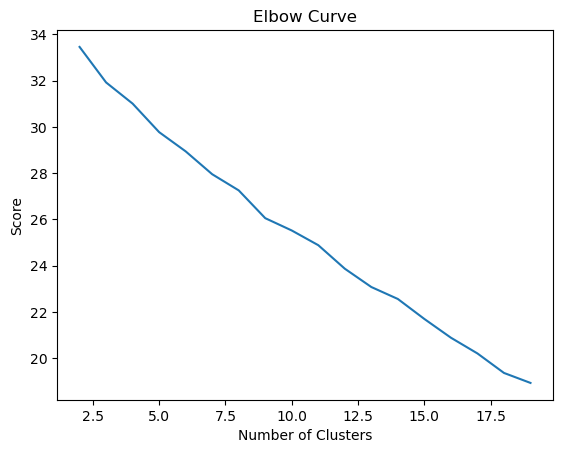

In [8]:
from sklearn.cluster import KMeans

Nc = range(2, 20)
#Incluye aquí un bucle de llamada al método *'fit()'* de KMeans con diferentes Ks (argumento n_clusters en la función KMeans) 
#y almacena en una lista llamada 'score' los valores *'inertia_'* de cada ejecución.
score = []   

# Bucle de entrenamiento de KMeans para cada valor de K
for k in Nc:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=123)
    km.fit(data_normalized)  # Usamos la matriz normalizada
    score.append(km.inertia_)  # Guardamos la inercia del clustering


#Este código visualiza la curva
#plt es la importación de matplotlib.pyplot
plt.plot(Nc,score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

#### Uso de la PCA para trabajar con menos dimensionalidad
Como ves, la curva del número de clusters sale poco parecida a la curva tipo 'codo' (elbow curve) que deseamos. Esto es debido al gran número de dimensiones de los datos, que enmascara la información relevante para clusterizar.
Vamos a reducir las dimensiones de nuestro dataset usando PCA.
Primero vamos a hacer una PCA sin reducción de dimensiones para ver la importancia relativa de los autovectores y así decidir el número de dimensiones.

Para ello llamamos a la función PCA() de scikit-learn con nuestro dataset y nos fijamos en el atributo *'explained_variance_ratio_'* que indica el porcentaje de varianza que tiene cada dimensión fijada por los autovectores ordenada de mayor a menor.

Varianza explicada por cada componente principal:
[8.04404689e-02 5.19094992e-02 4.36165478e-02 3.45087572e-02
 3.27412627e-02 3.14581729e-02 3.03444349e-02 2.58773055e-02
 2.50243147e-02 2.44208855e-02 2.38435957e-02 2.21524499e-02
 2.18475042e-02 2.12363637e-02 2.01636425e-02 1.99710713e-02
 1.94534505e-02 1.84696307e-02 1.80950586e-02 1.75619213e-02
 1.69351391e-02 1.62717571e-02 1.61155228e-02 1.57215124e-02
 1.53369877e-02 1.51309538e-02 1.49817207e-02 1.41739316e-02
 1.37499692e-02 1.34650706e-02 1.30974534e-02 1.29956985e-02
 1.21881813e-02 1.20508896e-02 1.19313317e-02 1.16792927e-02
 1.13531186e-02 1.11888215e-02 1.07344111e-02 1.04579645e-02
 1.03078845e-02 9.96366611e-03 9.70631542e-03 9.52800441e-03
 9.14422560e-03 8.98942165e-03 8.55160526e-03 8.38159223e-03
 8.04082170e-03 7.88500173e-03 7.81652350e-03 7.63905575e-03
 7.16085098e-03 6.92838481e-03 6.62759143e-03 6.06418144e-03
 5.59293281e-03 5.27082236e-03 3.70505274e-03 3.32317452e-32]


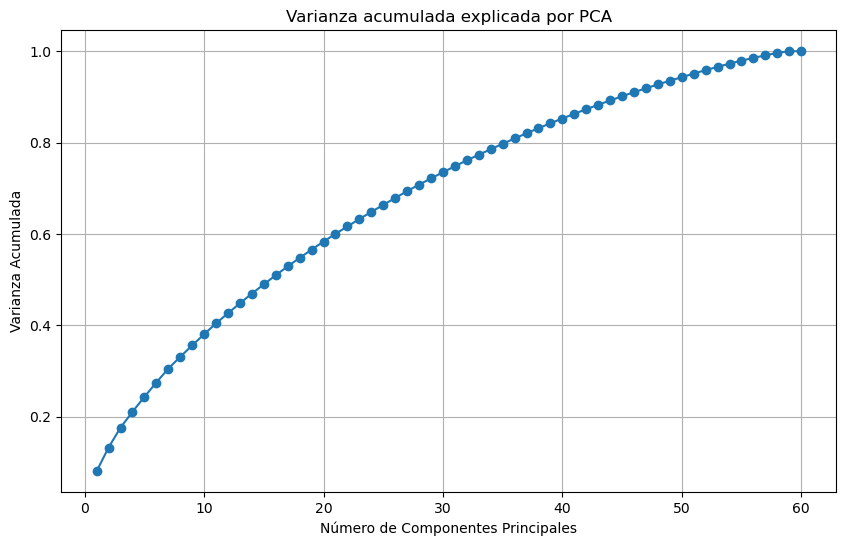

In [10]:
from sklearn.decomposition import PCA
pca = PCA()
#llama aquí al método pca.fit_transform() con el dataset  y recoge los datos transformados
data_pca = pca.fit_transform(data_normalized)

print("Varianza explicada por cada componente principal:")
print(pca.explained_variance_ratio_)

explained_variance_cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance_cumsum)+1), explained_variance_cumsum, marker='o')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza acumulada explicada por PCA')
plt.grid(True)
plt.show()

**Pregunta:** Observa el resultado de los 60 valores que te aparecen y que explican la varianza. ¿Hay grandes variaciones entre ellos? ¿A qué piensas que es debido (considera qué es cada una de las características que estamos usando)?

#Contestación:

No hay una gran diferencia entre ninguno de los valores de la varianza explicada, esto es debido a que lo que estamos analizando es una serie temporal. Por lo que en este caso el uso de PCA no seria una buena idea si queremos obtener la mayor varianza explicada posible, por lo menos con los datos originales.

Vamos a quedarnos con los 5 primeros autovalores/autovectores y vamos a vover a repetir la curva para ver si mejora en su forma. Pon en el cuadro de abajo el código otra vez de la PCA pero con el argumento 'n_components=5' y usa los datos, transformados ahora por esta nueva PCA, para generar la curva 'elbow curve'. Debes notar una mejoría en la forma de la misma. Esta curva nos da información de los valores de 'K' candidatos a hacer un buen Kmeans.

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

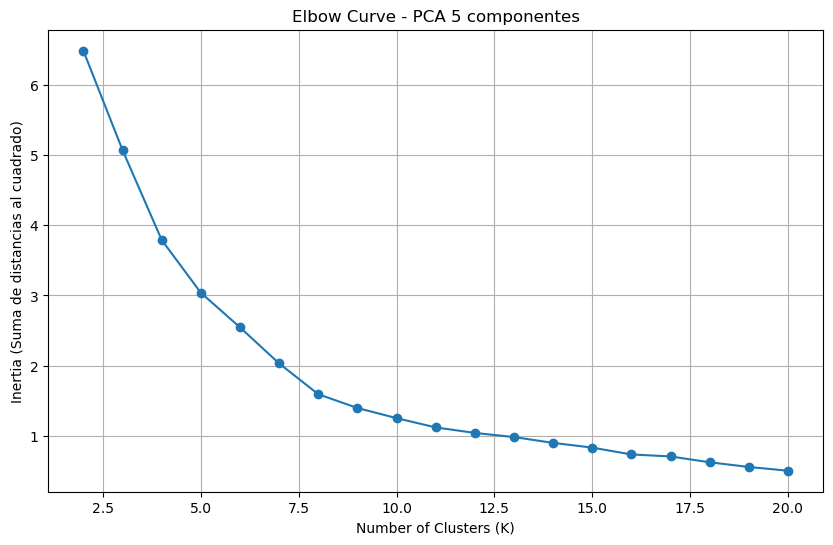

In [11]:
#Escribe aquí otra vez el código de la curva 'elbow' para los datos transformados con la PCA teniendo en cuenta las 5 primeras componentes principales.

pca_5 = PCA(n_components=5)
data_pca5 = pca_5.fit_transform(data_normalized)

# === Curva Elbow para los datos transformados ===
Nc = range(2, 21)  # Evaluamos K desde 2 hasta 20
score = []

for k in Nc:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=123)
    km.fit(data_pca5)  # Usamos los datos reducidos a 5 dimensiones
    score.append(km.inertia_)

# Visualización de la Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(Nc, score, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Suma de distancias al cuadrado)')
plt.title('Elbow Curve - PCA 5 componentes')
plt.grid(True)
plt.show()

## Análisis definitivo con KMeans
Se trata ahora de elegir el valor k que da mejor resultado dentro del rango adecuado indicado por la curva elbow. Recuerda que vamos a trabajar con el dataset generado por la proyección del original sobre los autovectores de la PCA.

**Cuestión** Valora la curva Elbow que has encontrado ahora respecto de la obtenida anteriormente. Indica el rango posible de valores de k donde debes buscar el mejor posible agrupamiento. 

Los posibles valores para el valor de K irian desde 5 hasta 8, que es donde mas "pronunciado" es el cambio en la curva.

Vamos a realizar un estudio del dataset usando K-Means. 
**Actividad 0** A partir del rango de valores que has elegido, repite el Kmeans con cada uno de los valores de K de este rango siguiendo las cajas siguientes y realizando la Actividad 1 y la Actividad 2 para cada valor.
Apóyate en los indicadores de calidad de las agrupaciones (como el mapa de calor y el indicador Silhouette) para justificar cuantitativamente tus elecciones o mostrar discrepancias que te surjan de estos indicadores con respecto al agrupamiento que obtienes (ya que conoces la solución).


In [13]:
kmeans = KMeans(n_clusters=7)#introduce un valor de K
kmeans.fit(data_pca5)#Introduce el dataset transformado y calcula el modelo
y_kmeans = kmeans.predict(data_pca5) #etiquetas de pertenencia a un cluster

#Hacemos un nuevo DataFrame con dos columnas, el nombre de la compañía y la etiqueta del cluster correspondiente.
#Imprimimos la lista
newframe=pd.DataFrame({"comp":company_names, "class":y_kmeans})  #He llamado 'companies' a la lista de compañías que has debido crear
                                                            #en la primera caja de código de este notebook
print(newframe.sort_values("class"))

                                  comp  class
4                               Boeing      0
11                               Cisco      0
14                                Dell      0
22                                  HP      0
24                               Intel      0
29                     Lookheed Martin      0
23                                 IBM      0
33                           Microsoft      0
51                   Texas instruments      0
47                            Symantec      0
36                    Northrop Grumman      0
58                               Xerox      0
19                     GlaxoSmithKline      1
42                   Royal Dutch Shell      1
46                      Sanofi-Aventis      1
6             British American Tobacco      1
37                            Novartis      1
43                                 SAP      1
52                            Unilever      1
49                               Total      1
56                            Wal-

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Puedes visualizar los clusters y los centroides usando las dos primeras componentes de los datos adaptando el siguiente código.
**Nota** En la expresión siguiente, la base de datos 'dtnorm' hace referencia a la base de datos normalizada y proyectada tras la PCA.

**Nota2:** Puedes usar otras componentes que no sean la 0 y la 1 para ver si obtienes mejores visualizaciones. No te olvides de que si modificas los índices de 'dtnorm' tambien debes modificar a los mismos índices 'centers'. 

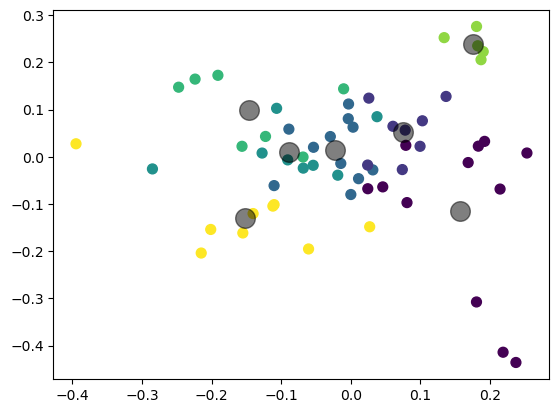

In [19]:
dtnorm = data_pca5
plt.scatter(dtnorm[:, 3], dtnorm[:, 4], c=y_kmeans, s=50, cmap='viridis') #He llamado 'dtnorm' al dataset  transformado por el PCA

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 3], centers[:, 4], c='black', s=200, alpha=0.5);
plt.show()

**Actividad 1:** Visualiza además también lo resultados usando el indicador Silhouette y un mapa de calor.

In [21]:
from sklearn.metrics import silhouette_score,silhouette_samples
from yellowbrick.cluster import SilhouetteVisualizer

Silhouette Score K=7: 0.395


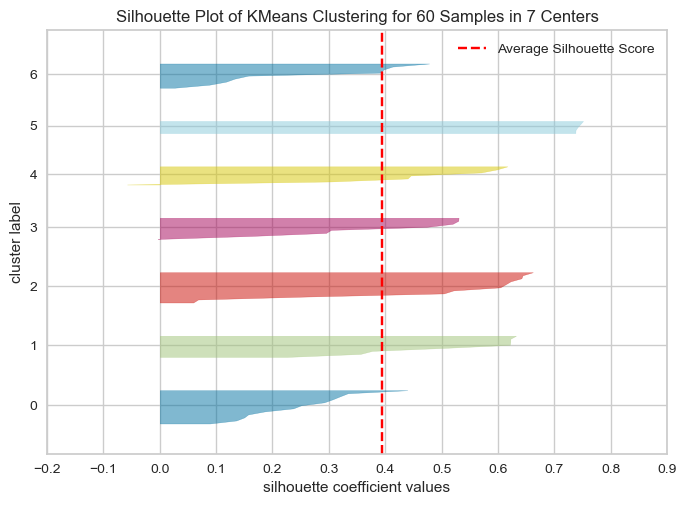

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 60 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [26]:
#Código para el indicador Silhouette
#Copia las instrucciones necesarias de la parte 1 de la práctica
score = silhouette_score(dtnorm, y_kmeans)
print(f"Silhouette Score K=7: {score:.3f}")

# Visualización gráfica
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(dtnorm)
visualizer.show()

(60, 6)
(60, 60)


<Axes: >

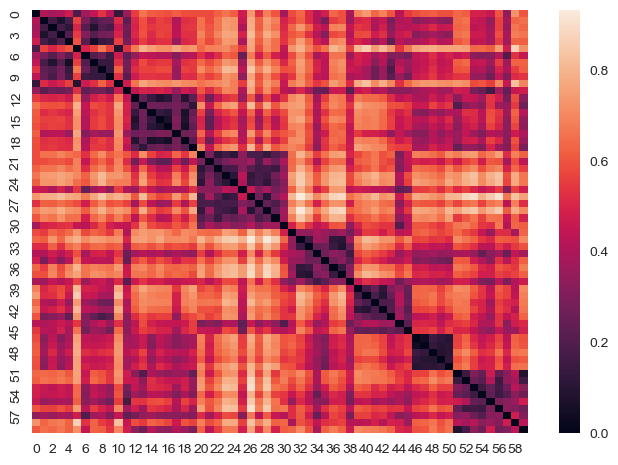

In [29]:
#código para el mapa de calor (HeatMap)
#El mapa de calor representa las distancias entre los pares de puntos ordenados por los clusters que
#ha generado K-Means
import scipy.spatial.distance as dist
import seaborn as sns

#Añade a tu matriz de datos una columna nueva con las etiquetas de K-Means llamadas 'y_kmeans'
newdata = np.hstack([dtnorm, y_kmeans.reshape(-1,1)]) 
#este valor debe ser (60,6)
print(newdata.shape)
#Ordena los datos por la etiquetas de los clusters de K-Means. Usa el metodo argsort() de numpy
newdatasorted = newdata[newdata[:, -1].argsort()]
#Nos quedamos con las 5 columnas de datos ordenadas por los clusters
X = newdatasorted[:, [0,1,2,3,4]]
#Calculo la matriz de distancias a partir de X con el metodo dist.pdist()
#Cuidado! Este método devuelve un vector, no una matriz. Hay que transformarlo a matriz. Lee 
#la ayuda online del método 'pdist()' porque allí te explica cómo hacerlo
Dist_vector = dist.pdist(X, metric='euclidean')
Dist = dist.squareform(Dist_vector)
print(Dist.shape) #debe darte (60,60)

#Dibuja el mapa de calor
sns.heatmap(Dist)


Con K=7 el coeficiente de silhouette no es demasiado bueno, siendo de 0,395. En cambio el resultado en el mapa de calor es algo mejor, ya que se pueden distinguir los clusters distribuidos por la diagonal principal. Aunque algunos son mas compactos que otros.

**Actividad 2** Observa la lista ordenada de empresas y saca tus propias conclusiones a partir de esta lista y de los indicadores de calidad que has utilizado. Explica bien cómo te salen estos indicadores de calidad. Anótalas en la caja de texto de abajo. 
Asegúrate de que conoces el sector industrial al que se dedica cada empresa para juzgar los clusters (consulta Google)



Repite estos cálculos y tus conclusiones para todos los valores del rango elegido.

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                                  comp  class
0                                Apple      0
2                               Amazon      0
14                                Dell      0
17                     Google/Alphabet      0
24                               Intel      0
30                          MasterCard      0
23                                 IBM      0
33                           Microsoft      0
51                   Texas instruments      0
50  Taiwan Semiconductor Manufacturing      0
47                            Symantec      0
59                               Yahoo      0
13                   DuPont de Nemours      1
18                       Goldman Sachs      1
29                     Lookheed Martin      1
1                                  AIG      1
16                   General Electrics      1
35                            Navistar      1
44                        Schlumberger      1
26                      JPMorgan Chase      1
58                               X

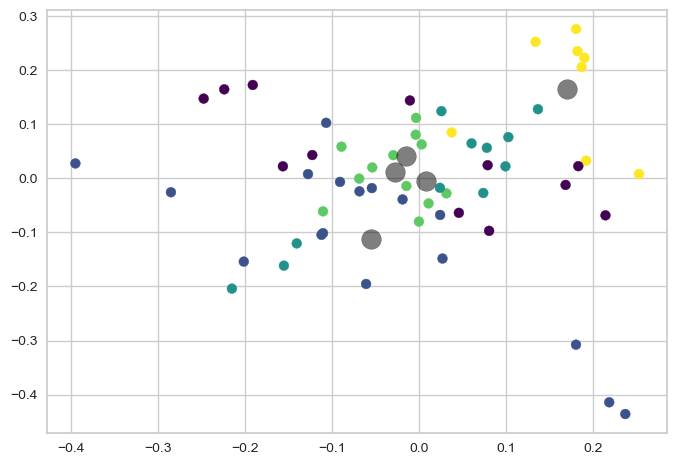

Silhouette Score K=5: 0.305


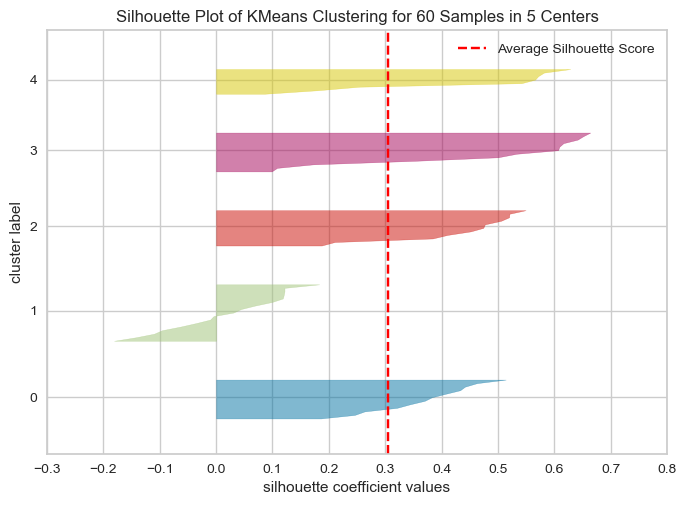

(60, 6)
(60, 60)


<Axes: >

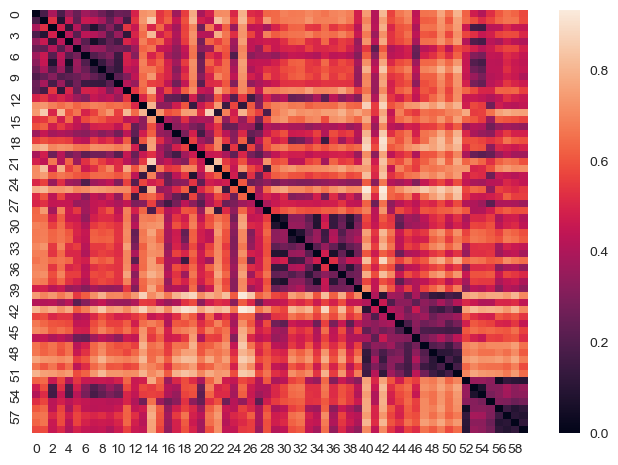

In [38]:
kmeans = KMeans(n_clusters=5)#introduce un valor de K
kmeans.fit(data_pca5)#Introduce el dataset transformado y calcula el modelo
y_kmeans = kmeans.predict(data_pca5) #etiquetas de pertenencia a un cluster

#Hacemos un nuevo DataFrame con dos columnas, el nombre de la compañía y la etiqueta del cluster correspondiente.
#Imprimimos la lista
newframe=pd.DataFrame({"comp":company_names, "class":y_kmeans})  #He llamado 'companies' a la lista de compañías que has debido crear
                                                            #en la primera caja de código de este notebook
print(newframe.sort_values("class"))

dtnorm = data_pca5
plt.scatter(dtnorm[:, 3], dtnorm[:, 4], c=y_kmeans, s=50, cmap='viridis') #He llamado 'dtnorm' al dataset  transformado por el PCA

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 3], centers[:, 4], c='black', s=200, alpha=0.5);
plt.show()

#Código para el indicador Silhouette
#Copia las instrucciones necesarias de la parte 1 de la práctica
score = silhouette_score(dtnorm, y_kmeans)
print(f"Silhouette Score K=5: {score:.3f}")

# Visualización gráfica
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(dtnorm)
visualizer.show()

#Añade a tu matriz de datos una columna nueva con las etiquetas de K-Means llamadas 'y_kmeans'
newdata = np.hstack([dtnorm, y_kmeans.reshape(-1,1)]) 
#este valor debe ser (60,6)
print(newdata.shape)
#Ordena los datos por la etiquetas de los clusters de K-Means. Usa el metodo argsort() de numpy
newdatasorted = newdata[newdata[:, -1].argsort()]
#Nos quedamos con las 5 columnas de datos ordenadas por los clusters
X = newdatasorted[:, [0,1,2,3,4]]
#Calculo la matriz de distancias a partir de X con el metodo dist.pdist()
#Cuidado! Este método devuelve un vector, no una matriz. Hay que transformarlo a matriz. Lee 
#la ayuda online del método 'pdist()' porque allí te explica cómo hacerlo
Dist_vector = dist.pdist(X, metric='euclidean')
Dist = dist.squareform(Dist_vector)
print(Dist.shape) #debe darte (60,60)

#Dibuja el mapa de calor
sns.heatmap(Dist)


Con K=5 el coeficiente sigue siendo muy malo (0,3), observando la grafica podriamos decir que los clusters son dispersos y que podria haber superposicion en alguno de ellos. El resultado en el mapa de calor es bastante malo. 

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                                  comp  class
6             British American Tobacco      0
12                             Chevron      0
19                     GlaxoSmithKline      0
52                            Unilever      0
43                                 SAP      0
42                   Royal Dutch Shell      0
46                      Sanofi-Aventis      0
37                            Novartis      0
57                               Exxon      0
49                               Total      0
26                      JPMorgan Chase      1
7                                Canon      1
15                                Ford      1
21                               Honda      1
18                       Goldman Sachs      1
5                      Bank of America      1
45                                Sony      1
48                              Toyota      1
34                          Mitsubishi      1
55                         Wells Fargo      1
56                            Wal-

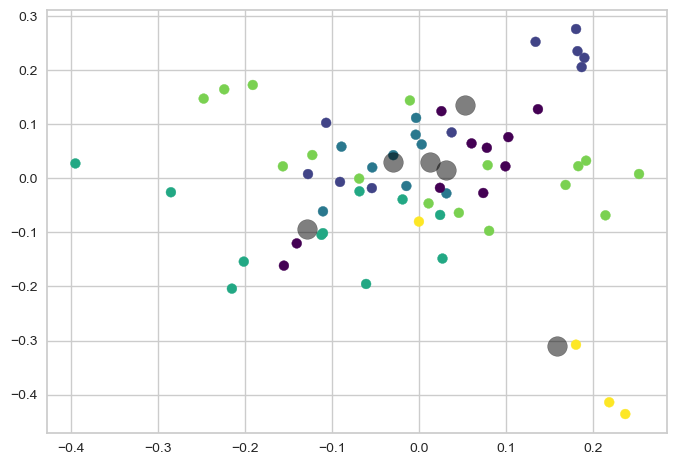

Silhouette Score K=6: 0.341


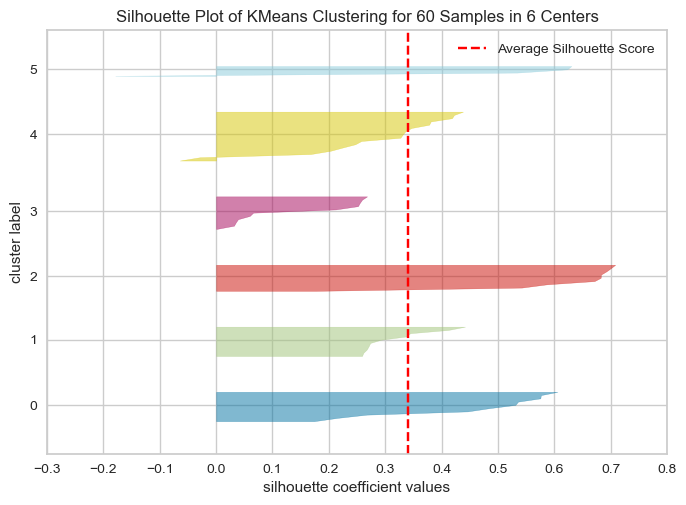

(60, 6)
(60, 60)


<Axes: >

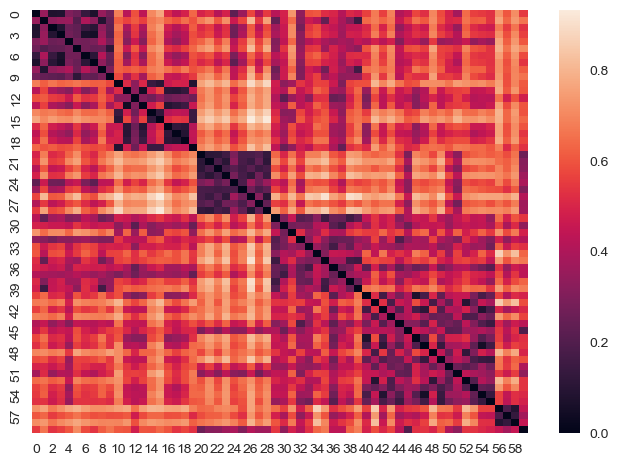

In [37]:
kmeans = KMeans(n_clusters=6)#introduce un valor de K
kmeans.fit(data_pca5)#Introduce el dataset transformado y calcula el modelo
y_kmeans = kmeans.predict(data_pca5) #etiquetas de pertenencia a un cluster

#Hacemos un nuevo DataFrame con dos columnas, el nombre de la compañía y la etiqueta del cluster correspondiente.
#Imprimimos la lista
newframe=pd.DataFrame({"comp":company_names, "class":y_kmeans})  #He llamado 'companies' a la lista de compañías que has debido crear
                                                            #en la primera caja de código de este notebook
print(newframe.sort_values("class"))

dtnorm = data_pca5
plt.scatter(dtnorm[:, 3], dtnorm[:, 4], c=y_kmeans, s=50, cmap='viridis') #He llamado 'dtnorm' al dataset  transformado por el PCA

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 3], centers[:, 4], c='black', s=200, alpha=0.5);
plt.show()

#Código para el indicador Silhouette
#Copia las instrucciones necesarias de la parte 1 de la práctica
score = silhouette_score(dtnorm, y_kmeans)
print(f"Silhouette Score K=6: {score:.3f}")

# Visualización gráfica
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(dtnorm)
visualizer.show()

#Añade a tu matriz de datos una columna nueva con las etiquetas de K-Means llamadas 'y_kmeans'
newdata = np.hstack([dtnorm, y_kmeans.reshape(-1,1)]) 
#este valor debe ser (60,6)
print(newdata.shape)
#Ordena los datos por la etiquetas de los clusters de K-Means. Usa el metodo argsort() de numpy
newdatasorted = newdata[newdata[:, -1].argsort()]
#Nos quedamos con las 5 columnas de datos ordenadas por los clusters
X = newdatasorted[:, [0,1,2,3,4]]
#Calculo la matriz de distancias a partir de X con el metodo dist.pdist()
#Cuidado! Este método devuelve un vector, no una matriz. Hay que transformarlo a matriz. Lee 
#la ayuda online del método 'pdist()' porque allí te explica cómo hacerlo
Dist_vector = dist.pdist(X, metric='euclidean')
Dist = dist.squareform(Dist_vector)
print(Dist.shape) #debe darte (60,60)

#Dibuja el mapa de calor
sns.heatmap(Dist)


Con K=6 el coeficiente sigue siendo muy malo (0,341), observando la grafica podriamos decir que los clusters son dispersos y que podria haber superposicion en alguno de ellos. El resultado en el mapa de calor es bastante malo, observamos incluso una posible superposicion entre clusters.

C:\Users\victo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


                                  comp  class
0                                Apple      0
2                               Amazon      0
30                          MasterCard      0
17                     Google/Alphabet      0
50  Taiwan Semiconductor Manufacturing      0
59                               Yahoo      0
20                          Home Depot      1
25                   Johnson & Johnson      1
28                           Coca Cola      1
31                           McDonalds      1
56                            Wal-Mart      1
54                            Walgreen      1
39                              Pfizer      1
38                               Pepsi      1
9                    Colgate-Palmolive      1
27                      Kimberly-Clark      1
40                      Procter Gamble      1
41                       Philip Morris      1
18                       Goldman Sachs      2
1                                  AIG      2
5                      Bank of Ame

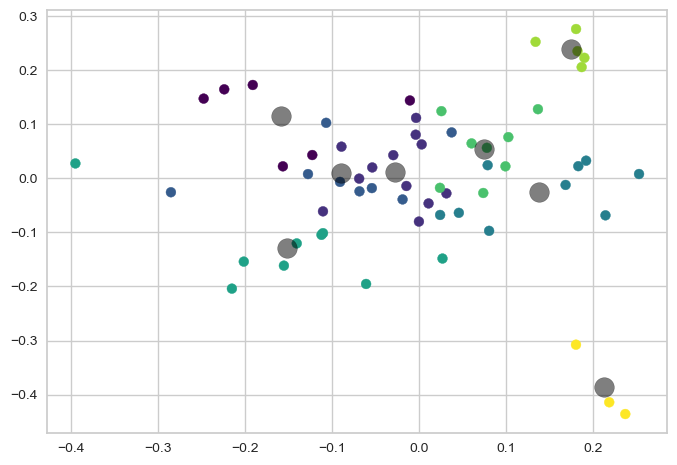

Silhouette Score K=8: 0.441


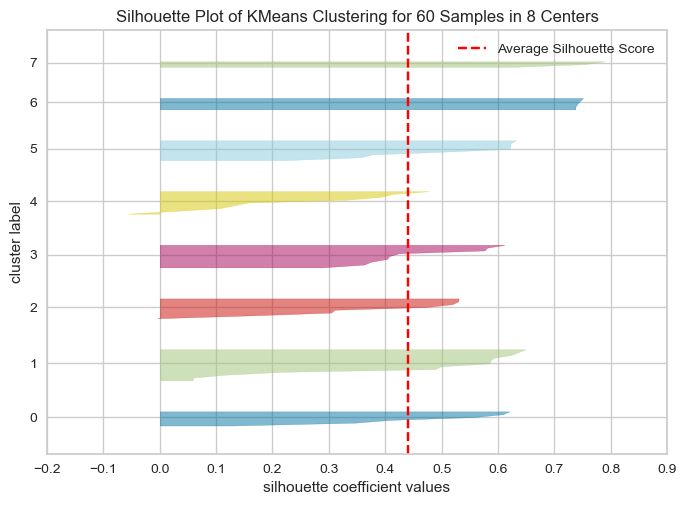

(60, 6)
(60, 60)


<Axes: >

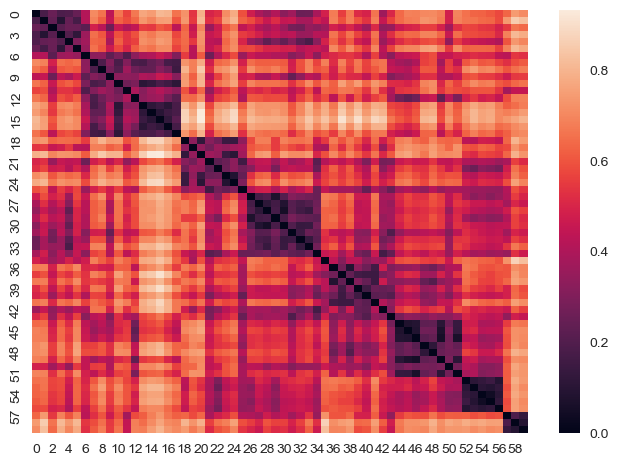

In [36]:
kmeans = KMeans(n_clusters=8)#introduce un valor de K
kmeans.fit(data_pca5)#Introduce el dataset transformado y calcula el modelo
y_kmeans = kmeans.predict(data_pca5) #etiquetas de pertenencia a un cluster

#Hacemos un nuevo DataFrame con dos columnas, el nombre de la compañía y la etiqueta del cluster correspondiente.
#Imprimimos la lista
newframe=pd.DataFrame({"comp":company_names, "class":y_kmeans})  #He llamado 'companies' a la lista de compañías que has debido crear
                                                            #en la primera caja de código de este notebook
print(newframe.sort_values("class"))

dtnorm = data_pca5
plt.scatter(dtnorm[:, 3], dtnorm[:, 4], c=y_kmeans, s=50, cmap='viridis') #He llamado 'dtnorm' al dataset  transformado por el PCA

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 3], centers[:, 4], c='black', s=200, alpha=0.5);
plt.show()

#Código para el indicador Silhouette
#Copia las instrucciones necesarias de la parte 1 de la práctica
score = silhouette_score(dtnorm, y_kmeans)
print(f"Silhouette Score K=8: {score:.3f}")

# Visualización gráfica
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick')
visualizer.fit(dtnorm)
visualizer.show()

#Añade a tu matriz de datos una columna nueva con las etiquetas de K-Means llamadas 'y_kmeans'
newdata = np.hstack([dtnorm, y_kmeans.reshape(-1,1)]) 
#este valor debe ser (60,6)
print(newdata.shape)
#Ordena los datos por la etiquetas de los clusters de K-Means. Usa el metodo argsort() de numpy
newdatasorted = newdata[newdata[:, -1].argsort()]
#Nos quedamos con las 5 columnas de datos ordenadas por los clusters
X = newdatasorted[:, [0,1,2,3,4]]
#Calculo la matriz de distancias a partir de X con el metodo dist.pdist()
#Cuidado! Este método devuelve un vector, no una matriz. Hay que transformarlo a matriz. Lee 
#la ayuda online del método 'pdist()' porque allí te explica cómo hacerlo
Dist_vector = dist.pdist(X, metric='euclidean')
Dist = dist.squareform(Dist_vector)
print(Dist.shape) #debe darte (60,60)

#Dibuja el mapa de calor
sns.heatmap(Dist)


Con K=8 obtenemos el mejor score, siendo de 0,4. Sigue sin ser excesivamente bueno pero es algo mejor que los anteriores. Ademas, el mapa de calor es bueno, acumulando los puntos mas oscuros (los de menor distancia entre ellos) en la diagonal principal, pudiendo identificar los clusters visualmente.

Nombres: Yoana Boyanova Boncheva y Víctor Piquero Moreno